In [217]:
import pandas as pd
import numpy as np
from preparing_data import *
from catboost import CatBoostClassifier, Pool
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [218]:
df = pd.read_parquet("history_data.parquet")

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224860 entries, 0 to 224859
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  224860 non-null  datetime64[ns]
 1   open       224860 non-null  float64       
 2   high       224860 non-null  float64       
 3   low        224860 non-null  float64       
 4   close      224860 non-null  float64       
 5   volume     224860 non-null  float64       
 6   symbol     224860 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 12.0+ MB


In [220]:
def calculate_max_drawdown(series):
    rolling_max = series.cummax()
    drawdown = (series - rolling_max) / rolling_max
    return drawdown.cummin()

df = df.sort_values(["symbol", "timestamp"])
df["ret_1"] = df.groupby("symbol")["close"].pct_change()
df = df.fillna(0)
closed = df.groupby("symbol")["close"]
windows = (1,7,20,50)
for window in windows:
    
    df[f"ret_{window}"] = closed.pct_change(window)

    df[f"vol_{window}"] = (
        df.groupby("symbol")["ret_1"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"volume_z_{window}"] = (
        df.groupby("symbol")["volume"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )

    df[f"price_z_{window}"] = (
        df.groupby("symbol")["close"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )
    df[f"high_{window}"] = df.groupby("symbol")["high"].transform(
    lambda x: x.rolling(window).max().shift(1)
    )

df["net_return"] = closed.transform(lambda x: (x / x.iloc[0]) - 1)
df["max_drawdown"] = closed.transform(calculate_max_drawdown)

future_return = df.groupby("symbol")["close"].transform(
lambda x: x.pct_change(3).shift(-3)
)

df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

df["signal_long"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 1)
).astype(int)

# df["target_good_trade"] = (future_return > 0.02).astype(int)


df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

btc = df[df["symbol"] == "BTCUSDT"][["timestamp", "ret_1", "ret_7", "ret_20", "ret_50" ,"vol_20", "vol_50"]].copy()

btc = btc.rename(columns={
    "ret_1": "btc_ret_1",
    "ret_7": "btc_ret_7",
    "ret_20": "btc_ret_20",
    "ret_50": "btc_ret_50",
    "vol_20": "btc_vol_20",
    "vol_50": "btc_vol_50",
})

df = df.merge(btc, on="timestamp", how="left")

df["rel_ret_7"] = df["ret_7"] - df["btc_ret_7"]
df["rel_ret_20"] = df["ret_20"] - df["btc_ret_20"]
df["rel_ret_50"] = df["ret_50"] - df["btc_ret_50"]

delta = df.groupby("symbol")["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / (avg_loss + 1e-12)

df["rsi_14"] = 100 - (100 / (1 + rs))

df["signal_breakout"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 0.5)
).astype(int)

df["signal_mean_reversion"] = (
    (df["rsi_14"] < 35) &
    (df["price_z_20"] < -1.0)
).astype(int)
display(df)

,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,btc_ret_20,btc_ret_50,btc_vol_20,btc_vol_50,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,signal_breakout,signal_mean_reversion
0,2025-12-09 18:00:00,188.9900,197.2300,187.7000,196.3700,18207.878,AAVEUSDT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2025-12-09 19:00:00,196.3800,204.9300,196.3800,204.6500,26802.688,AAVEUSDT,0.042165,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2025-12-09 20:00:00,204.6600,206.3200,202.9600,205.0900,17590.349,AAVEUSDT,0.002150,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2025-12-09 21:00:00,205.1000,205.8500,203.5500,204.3500,7925.111,AAVEUSDT,-0.003608,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2025-12-09 22:00:00,204.3600,205.9400,203.2300,204.9600,5955.177,AAVEUSDT,0.002985,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224855,2026-07-05 21:00:00,1.1346,1.1403,1.1345,1.1361,958392.800,XRPUSDT,0.001234,NaN,NaN,...,-0.005771,0.011521,0.002089,0.002454,0.001046,-0.016686,0.007311,46.728972,0,0
224856,2026-07-05 22:00:00,1.1360,1.1381,1.1336,1.1352,1389940.900,XRPUSDT,-0.000792,NaN,NaN,...,-0.005941,0.009243,0.002090,0.002452,-0.000821,-0.013240,0.001171,48.076923,0,0
224857,2026-07-05 23:00:00,1.1352,1.1381,1.1346,1.1373,1201165.800,XRPUSDT,0.001850,NaN,NaN,...,-0.004138,0.008466,0.002032,0.002454,0.002563,-0.006475,0.000763,48.076923,0,0
224858,2026-07-06 00:00:00,1.1374,1.1484,1.1351,1.1446,2461171.600,XRPUSDT,0.006419,NaN,NaN,...,0.003245,0.014178,0.002398,0.002579,0.002053,-0.003943,-0.002958,55.737705,0,0


In [221]:
horizon = 3
fee = 0.001

df["entry_price"] = df.groupby("symbol")["open"].shift(-1)
df["exit_price"] = df.groupby("symbol")["close"].shift(-horizon)

future_lows = []

for i in range(1, horizon + 1):
    future_lows.append(df.groupby("symbol")["low"].shift(-i))

df["future_min_low"] = pd.concat(future_lows, axis=1).min(axis=1)

df["net_return"] = df["exit_price"] / df["entry_price"] - 1 - 2 * fee
df["max_drawdown"] = df["future_min_low"] / df["entry_price"] - 1

df["target_good_trade"] = (
    (df["net_return"] > 0.002) &
    (df["max_drawdown"] > -0.015)
).astype(int)

In [222]:
df = df.fillna(0)
df


,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,signal_breakout,signal_mean_reversion,entry_price,exit_price,future_min_low,target_good_trade
0,2025-12-09 18:00:00,188.9900,197.2300,187.7000,196.3700,18207.878,AAVEUSDT,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,196.3800,204.3500,196.3800,1
1,2025-12-09 19:00:00,196.3800,204.9300,196.3800,204.6500,26802.688,AAVEUSDT,0.042165,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,204.6600,204.9600,202.9600,0
2,2025-12-09 20:00:00,204.6600,206.3200,202.9600,205.0900,17590.349,AAVEUSDT,0.002150,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,205.1000,203.3200,201.0500,0
3,2025-12-09 21:00:00,205.1000,205.8500,203.5500,204.3500,7925.111,AAVEUSDT,-0.003608,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,204.3600,201.9400,201.0500,0
4,2025-12-09 22:00:00,204.3600,205.9400,203.2300,204.9600,5955.177,AAVEUSDT,0.002985,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,204.9500,205.1900,201.0500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224855,2026-07-05 21:00:00,1.1346,1.1403,1.1345,1.1361,958392.800,XRPUSDT,0.001234,0.0,0.0,...,0.001046,-0.016686,0.007311,46.728972,0,0,1.1360,1.1446,1.1336,1
224856,2026-07-05 22:00:00,1.1360,1.1381,1.1336,1.1352,1389940.900,XRPUSDT,-0.000792,0.0,0.0,...,-0.000821,-0.013240,0.001171,48.076923,0,0,1.1352,1.1556,1.1346,1
224857,2026-07-05 23:00:00,1.1352,1.1381,1.1346,1.1373,1201165.800,XRPUSDT,0.001850,0.0,0.0,...,0.002563,-0.006475,0.000763,48.076923,0,0,1.1374,0.0000,1.1351,0
224858,2026-07-06 00:00:00,1.1374,1.1484,1.1351,1.1446,2461171.600,XRPUSDT,0.006419,0.0,0.0,...,0.002053,-0.003943,-0.002958,55.737705,0,0,1.1446,0.0000,1.1425,0


In [223]:
feature_cols = [
    "symbol",
    "ret_1",
    "ret_7",
    "ret_20",
    "ret_50",
    "vol_7",
    "vol_20",
    "vol_50",
    "volume_z_20",
    "volume_z_50",
    "price_z_20",
    "price_z_50",
    "candle_range",
    "body_size",
    "btc_ret_1",
    "btc_ret_7",
    "btc_ret_50",
    "btc_vol_20",
    "btc_vol_50",
    "rel_ret_7",
    "rel_ret_20",
    "rel_ret_50",
    "rsi_14",
    "strategy_name",
    
]

breakout_trades = df[df["signal_breakout"] == 1].copy()
breakout_trades["strategy_name"] = "breakout"

mean_reversion_trades = df[df["signal_mean_reversion"] == 1].copy()
mean_reversion_trades["strategy_name"] = "mean_reversion"

ml_dataset = pd.concat(
    [breakout_trades, mean_reversion_trades],
    ignore_index=True
)

ml_dataset = ml_dataset[
    ["timestamp", "entry_price", "exit_price", "net_return", "max_drawdown", "target_good_trade"]
    + feature_cols
]

ml = ml_dataset.dropna().sort_values("timestamp")


In [224]:
display(
    ml,
    ml.info()
)

<class 'pandas.core.frame.DataFrame'>
Index: 44568 entries, 19397 to 3314
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          44568 non-null  datetime64[ns]
 1   entry_price        44568 non-null  float64       
 2   exit_price         44568 non-null  float64       
 3   net_return         44568 non-null  float64       
 4   max_drawdown       44568 non-null  float64       
 5   target_good_trade  44568 non-null  int64         
 6   symbol             44568 non-null  object        
 7   ret_1              44568 non-null  float64       
 8   ret_7              44568 non-null  float64       
 9   ret_20             44568 non-null  float64       
 10  ret_50             44568 non-null  float64       
 11  vol_7              44568 non-null  float64       
 12  vol_20             44568 non-null  float64       
 13  vol_50             44568 non-null  float64       
 14  volume_z

,timestamp,entry_price,exit_price,net_return,max_drawdown,target_good_trade,symbol,ret_1,ret_7,ret_20,...,btc_ret_1,btc_ret_7,btc_ret_50,btc_vol_20,btc_vol_50,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,strategy_name
19397,2025-12-10 13:00:00,1.48200,1.48800,0.002049,-0.003374,1,FILUSDT,-0.010681,-0.023715,0.000000,...,-0.006967,-0.001493,0.000000,0.00000,0.000000,-0.022223,0.000000,0.000000,24.242424,mean_reversion
16901,2025-12-10 13:00:00,7.85000,7.90000,0.004369,-0.001274,1,EGLDUSDT,-0.008827,-0.019950,0.000000,...,-0.006967,-0.001493,0.000000,0.00000,0.000000,-0.018457,0.000000,0.000000,19.354839,mean_reversion
39736,2025-12-10 13:00:00,0.27920,0.27820,-0.005582,-0.004298,0,TRXUSDT,-0.002144,-0.010280,0.000000,...,-0.006967,-0.001493,0.000000,0.00000,0.000000,-0.008787,0.000000,0.000000,19.696970,mean_reversion
37241,2025-12-10 13:00:00,0.34600,0.34700,0.000890,-0.002890,0,THETAUSDT,-0.011396,-0.016997,0.000000,...,-0.006967,-0.001493,0.000000,0.00000,0.000000,-0.015504,0.000000,0.000000,25.000000,mean_reversion
22085,2025-12-10 13:00:00,0.04556,0.04554,-0.002439,-0.005707,0,GRTUSDT,-0.011714,-0.014066,0.000000,...,-0.006967,-0.001493,0.000000,0.00000,0.000000,-0.012573,0.000000,0.000000,22.910217,mean_reversion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,2026-07-06 01:00:00,0.00000,0.00000,0.000000,0.000000,0,ATOMUSDT,0.002522,0.018578,0.012739,...,0.009432,0.015095,0.014498,0.00305,0.002601,0.003483,-0.003108,-0.026307,73.750000,breakout
1355,2026-07-06 01:00:00,0.00000,0.00000,0.000000,0.000000,0,BTCUSDT,0.009432,0.015095,0.015847,...,0.009432,0.015095,0.014498,0.00305,0.002601,0.000000,0.000000,0.000000,68.328593,breakout
1665,2026-07-06 01:00:00,0.00000,0.00000,0.000000,0.000000,0,DOGEUSDT,0.006288,0.016330,0.033610,...,0.009432,0.015095,0.014498,0.00305,0.002601,0.001235,0.017763,-0.009242,76.315789,breakout
6520,2026-07-06 01:00:00,0.00000,0.00000,0.000000,0.000000,0,XRPUSDT,0.009610,0.016359,0.016001,...,0.009432,0.015095,0.014498,0.00305,0.002601,0.001264,0.000154,-0.000369,68.260870,breakout


None

In [225]:
display(
    ml.shape,
    ml["target_good_trade"].value_counts(normalize=True),
    ml["strategy_name"].value_counts()
)

(44568, 30)

target_good_trade
0    0.674295
1    0.325705
Name: proportion, dtype: float64

strategy_name
mean_reversion    38047
breakout           6521
Name: count, dtype: int64

In [226]:
split = 0.8
ml = ml.sort_values("timestamp")

feature_cols = list(dict.fromkeys(feature_cols))

n = len(ml)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train = ml.iloc[:train_end].copy()
valid = ml.iloc[train_end:valid_end].copy()
test = ml.iloc[valid_end:].copy()

print("train:", train.shape)
print("valid:", valid.shape)
print("test:", test.shape)

# split_date = ml_dataset["timestamp"].quantile(split)

# train = ml_dataset[ml_dataset["timestamp"] <= split_date].copy()
# test = ml_dataset[ml_dataset["timestamp"] > split_date].copy()

train: (31197, 30)
valid: (6685, 30)
test: (6686, 30)


In [227]:
X_train = train[feature_cols].copy()
y_train = train["target_good_trade"]

X_valid = valid[feature_cols].copy()
y_valid = valid["target_good_trade"]

X_test = test[feature_cols].copy()
y_test = test["target_good_trade"]

In [228]:
cat_features = ["symbol", "strategy_name"]
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
valid_pool = Pool(data=X_valid,label=y_valid,cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)
predict_pool = Pool(data=X_test, cat_features=cat_features)

In [229]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.04,
    depth=4,
    # l2_leaf_reg=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42,
)

model.fit(
    X=train_pool,
    eval_set=valid_pool,
    early_stopping_rounds=50,   
)

0:	test: 0.5314053	best: 0.5314053 (0)	total: 27.2ms	remaining: 8.13s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5768223952
bestIteration = 15

Shrink model to first 16 iterations.


CatBoostClassifier(depth=4, eval_metric='AUC', iterations=300, learning_rate=0.04, loss_function='Logloss', random_seed=42, verbose=100)

In [230]:
valid_res = valid.copy()
valid_res["prob_good_trade"] = model.predict_proba(valid_pool)[:, 1]

thresholds = np.arange(0.30, 0.61, 0.01)
rows = []

for threshold in thresholds:
    tmp = valid_res[valid_res["prob_good_trade"] >= threshold]
    if len(tmp) == 0:
        continue
    rows.append({
        "threshold": threshold,
        "trades": len(tmp),
        "mean_return": tmp["net_return"].mean(),
        "winrate": (tmp["net_return"] > 0).mean(),
        "total_return": tmp["net_return"].sum(),
    })

threshold_table = pd.DataFrame(rows)
threshold_table.sort_values("total_return", ascending=False).head(15)
min_trades = 100
best_row = (
    threshold_table[threshold_table["trades"] >= min_trades]
    .sort_values("total_return", ascending=False)
    .iloc[0]
)
best_threshold = best_row["threshold"]
print(best_row)
print("best_threshold:", best_threshold)

threshold         0.440000
trades          186.000000
mean_return       0.005615
winrate           0.704301
total_return      1.044379
Name: 14, dtype: float64
best_threshold: 0.4400000000000001


trade_allowed
0    5661
1    1025
Name: count, dtype: int64

,timestamp,symbol,strategy_name,prob_good_trade,risk_score,target_good_trade,trade_allowed
21931,2026-05-31 20:00:00,GALAUSDT,mean_reversion,0.402117,0.597883,1,0
14198,2026-05-31 20:00:00,BTCUSDT,mean_reversion,0.336995,0.663005,0,0
25365,2026-05-31 20:00:00,LDOUSDT,mean_reversion,0.395504,0.604496,1,0
15839,2026-05-31 20:00:00,DOGEUSDT,mean_reversion,0.362699,0.637301,1,0
8159,2026-05-31 20:00:00,ADAUSDT,mean_reversion,0.373405,0.626595,0,0
...,...,...,...,...,...,...,...
6520,2026-07-06 01:00:00,XRPUSDT,breakout,0.389208,0.610792,0,0
5311,2026-07-06 01:00:00,THETAUSDT,breakout,0.405319,0.594681,0,0
2222,2026-07-06 01:00:00,FETUSDT,breakout,0.407704,0.592296,0,0
744,2026-07-06 01:00:00,ATOMUSDT,breakout,0.392790,0.607210,0,0


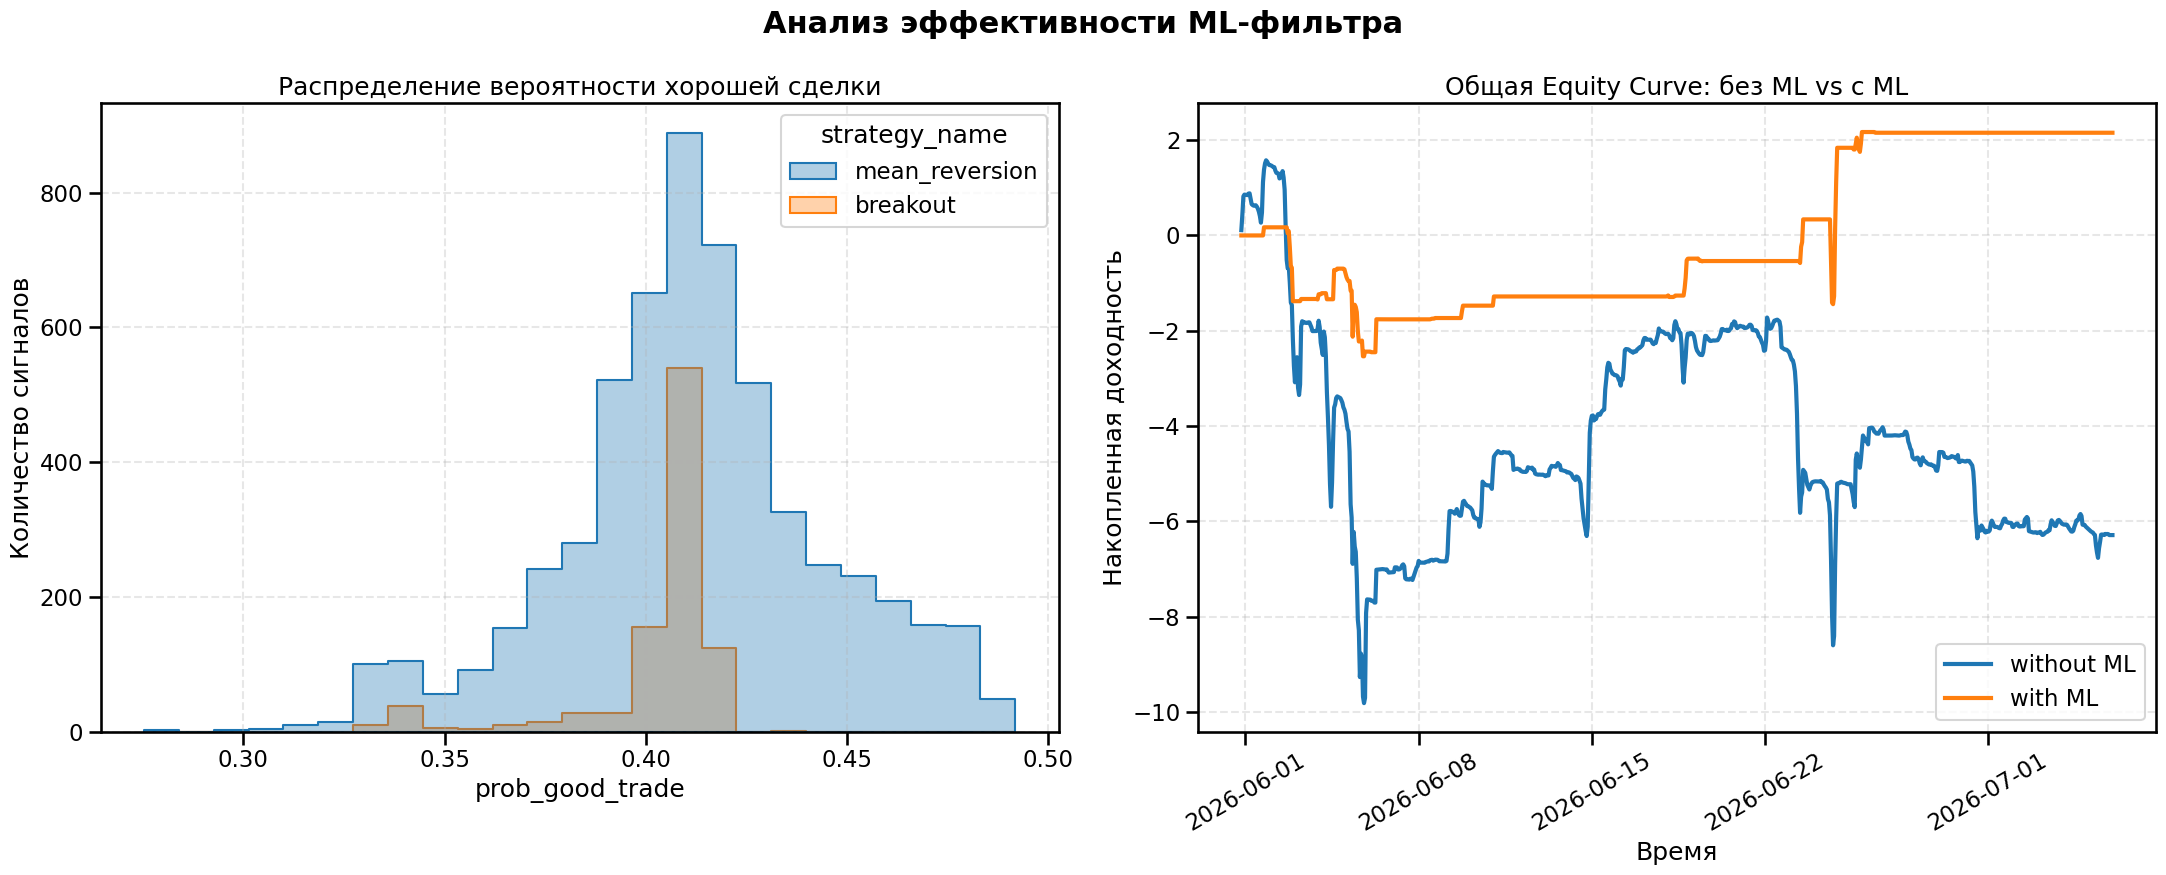

In [231]:
threshold = best_threshold 
test["prob_good_trade"] = model.predict_proba(predict_pool)[:, 1]
test["risk_score"] = 1 - test["prob_good_trade"]
test["trade_allowed"] = (test["prob_good_trade"] > threshold).astype(int)
test_res = test[["timestamp", "symbol", "strategy_name", "prob_good_trade", "risk_score", "target_good_trade", "trade_allowed"]]
display(test_res["trade_allowed"].value_counts())
display(test_res)

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
sns.set_context("talk")

test_res = test.copy()
test_res["timestamp"] = pd.to_datetime(test_res["timestamp"])
test_res = test_res.sort_values("timestamp")

# доходность без фильтра
test_res["return_without_ml"] = test_res["net_return"]

# доходность с ML-фильтром
test_res["return_with_ml"] = test_res["net_return"] * test_res["trade_allowed"]

# общий equity по всем стратегиям
equity_total = (
    test_res
    .groupby("timestamp", as_index=False)[["return_without_ml", "return_with_ml"]]
    .sum()
    .sort_values("timestamp")
)

equity_total["equity_without_ml"] = equity_total["return_without_ml"].cumsum()
equity_total["equity_with_ml"] = equity_total["return_with_ml"].cumsum()

# equity отдельно по стратегиям
equity_by_strategy = (
    test_res
    .groupby(["strategy_name", "timestamp"], as_index=False)[
        ["return_without_ml", "return_with_ml"]
    ]
    .sum()
    .sort_values(["strategy_name", "timestamp"])
)

equity_by_strategy["equity_without_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_without_ml"]
    .cumsum()
)

equity_by_strategy["equity_with_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_with_ml"]
    .cumsum()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

fig.suptitle(
    "Анализ эффективности ML-фильтра",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

# распределение вероятностей
sns.histplot(
    data=test_res,
    x="prob_good_trade",
    hue="strategy_name",
    bins=25,
    element="step",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)

axes[0].set_title("Распределение вероятности хорошей сделки")
axes[0].set_xlabel("prob_good_trade")
axes[0].set_ylabel("Количество сигналов")
axes[0].grid(True, alpha=0.3, linestyle="--")

# общий equity без ML и с ML
axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_without_ml"],
    label="without ML",
    linewidth=3,
)

axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_with_ml"],
    label="with ML",
    linewidth=3,
)

axes[1].set_title("Общая Equity Curve: без ML vs с ML")
axes[1].set_xlabel("Время")
axes[1].set_ylabel("Накопленная доходность")
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle="--")

axes[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

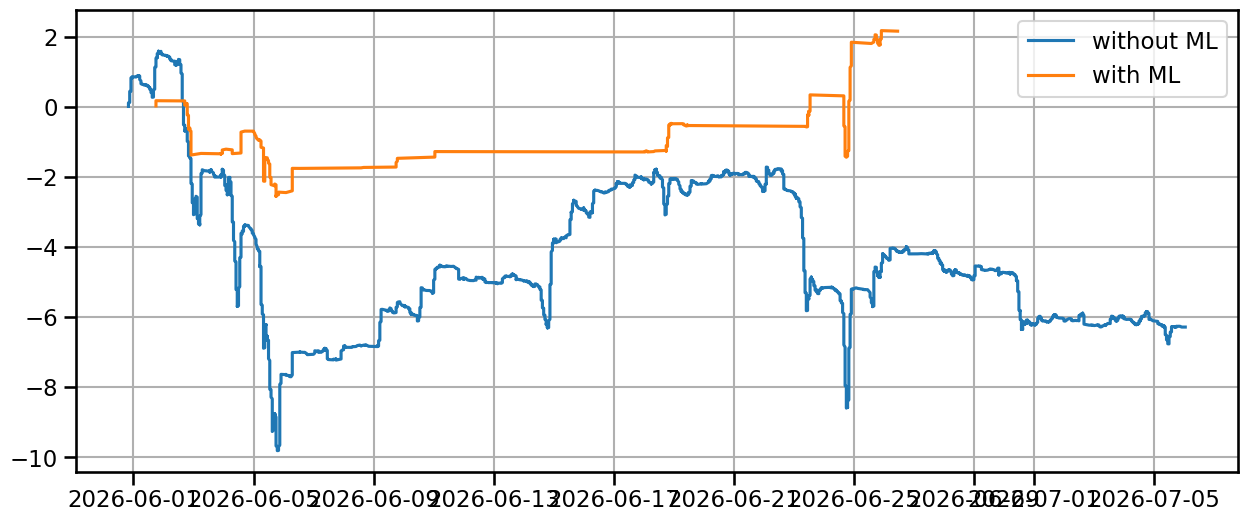

In [232]:
plot_all = test.sort_values("timestamp").copy()
plot_all["equity_without_ml"] = plot_all["net_return"].cumsum()

plot_ml = test[test["trade_allowed"] == 1].sort_values("timestamp").copy()
plot_ml["equity_with_ml"] = plot_ml["net_return"].cumsum()

plt.figure(figsize=(15, 6))
plt.plot(plot_all["timestamp"], plot_all["equity_without_ml"], label="without ML")
plt.plot(plot_ml["timestamp"], plot_ml["equity_with_ml"], label="with ML")
plt.legend()
plt.grid()
plt.show()

In [233]:
without_ml = test.copy()
with_ml = test[test["trade_allowed"] == 1].copy()

print("без ML:")
print("trades:", len(without_ml))
print("mean_return:", without_ml["net_return"].mean())
print("winrate:", (without_ml["net_return"] > 0).mean())
print("total_return:", without_ml["net_return"].sum())

print()

print("с ML:")
print("trades:", len(with_ml))
print("mean_return:", with_ml["net_return"].mean())
print("winrate:", (with_ml["net_return"] > 0).mean())
print("total_return:", with_ml["net_return"].sum())

без ML:
trades: 6686
mean_return: -0.0009402588917946807
winrate: 0.4593179778641938
total_return: -6.286570950539235

с ML:
trades: 1025
mean_return: 0.0021023891038267884
winrate: 0.5756097560975609
total_return: 2.154948831422458


In [234]:
feature_cols = list(dict.fromkeys(feature_cols))

cat_features = ["symbol", "strategy_name"]

train_days = 30
valid_days = 7
test_days = 7

min_train_size = 500
min_valid_size = 100
min_test_size = 100

all_test_results = []
window_stats = []

start_date = ml["timestamp"].min()
end_date = ml["timestamp"].max()

window_start = start_date

window_id = 0

while True:
    train_start = window_start
    train_end = train_start + pd.Timedelta(days=train_days)

    valid_start = train_end
    valid_end = valid_start + pd.Timedelta(days=valid_days)

    test_start = valid_end
    test_end = test_start + pd.Timedelta(days=test_days)

    if test_end > end_date:
        break

    train = ml[
        (ml["timestamp"] >= train_start) &
        (ml["timestamp"] < train_end)
    ].copy()

    valid = ml[
        (ml["timestamp"] >= valid_start) &
        (ml["timestamp"] < valid_end)
    ].copy()

    test = ml[
        (ml["timestamp"] >= test_start) &
        (ml["timestamp"] < test_end)
    ].copy()

    if len(train) < min_train_size or len(valid) < min_valid_size or len(test) < min_test_size:
        window_start += pd.Timedelta(days=test_days)
        continue

    if train["target_good_trade"].nunique() < 2:
        window_start += pd.Timedelta(days=test_days)
        continue

    X_train = train[feature_cols].copy()
    y_train = train["target_good_trade"]

    X_valid = valid[feature_cols].copy()
    y_valid = valid["target_good_trade"]

    X_test = test[feature_cols].copy()
    y_test = test["target_good_trade"]

    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_features
    )

    valid_pool = Pool(
        data=X_valid,
        label=y_valid,
        cat_features=cat_features
    )

    test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=cat_features
    )

    model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.04,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    model.fit(
        train_pool,
        eval_set=valid_pool,
        early_stopping_rounds=50,
        use_best_model=True
    )

    # подбираем threshold только на valid
    valid_res = valid.copy()
    valid_res["prob_good_trade"] = model.predict_proba(valid_pool)[:, 1]

    threshold_rows = []

    for threshold in np.arange(0.30, 0.61, 0.01):
        tmp = valid_res[valid_res["prob_good_trade"] >= threshold]

        if len(tmp) < 30:
            continue

        threshold_rows.append({
            "threshold": threshold,
            "trades": len(tmp),
            "mean_return": tmp["net_return"].mean(),
            "winrate": (tmp["net_return"] > 0).mean(),
            "total_return": tmp["net_return"].sum(),
        })

    if len(threshold_rows) == 0:
        window_start += pd.Timedelta(days=test_days)
        continue

    threshold_table = pd.DataFrame(threshold_rows)

    best_threshold = (
        threshold_table
        .sort_values("total_return", ascending=False)
        .iloc[0]["threshold"]
    )

    # проверяем на test
    test_res = test.copy()
    test_res["prob_good_trade"] = model.predict_proba(test_pool)[:, 1]
    test_res["risk_score"] = 1 - test_res["prob_good_trade"]

    test_res["trade_allowed"] = (
        test_res["prob_good_trade"] >= best_threshold
    ).astype(int)

    without_ml = test_res.copy()
    with_ml = test_res[test_res["trade_allowed"] == 1].copy()

    total_without_ml = without_ml["net_return"].sum()
    total_with_ml = with_ml["net_return"].sum()

    stats = {
        "window_id": window_id,
        "train_start": train_start,
        "train_end": train_end,
        "valid_start": valid_start,
        "valid_end": valid_end,
        "test_start": test_start,
        "test_end": test_end,
        "threshold": best_threshold,

        "trades_without_ml": len(without_ml),
        "trades_with_ml": len(with_ml),

        "mean_return_without_ml": without_ml["net_return"].mean(),
        "mean_return_with_ml": with_ml["net_return"].mean(),

        "winrate_without_ml": (without_ml["net_return"] > 0).mean(),
        "winrate_with_ml": (with_ml["net_return"] > 0).mean(),

        "total_return_without_ml": total_without_ml,
        "total_return_with_ml": total_with_ml,

        "improvement": total_with_ml - total_without_ml,
        "model_best_iteration": model.get_best_iteration(),
    }

    window_stats.append(stats)

    test_res["window_id"] = window_id
    test_res["threshold"] = best_threshold

    all_test_results.append(test_res)

    print(
        f"window {window_id}: "
        f"without_ml={total_without_ml:.4f}, "
        f"with_ml={total_with_ml:.4f}, "
        f"improvement={total_with_ml - total_without_ml:.4f}, "
        f"threshold={best_threshold:.2f}"
    )

    window_id += 1
    window_start += pd.Timedelta(days=test_days)

window 0: without_ml=-3.1956, with_ml=-1.0410, improvement=2.1547, threshold=0.38
window 1: without_ml=-10.6221, with_ml=-0.1353, improvement=10.4868, threshold=0.50
window 2: without_ml=-19.9536, with_ml=-7.5776, improvement=12.3760, threshold=0.47
window 3: without_ml=2.3166, with_ml=0.0000, improvement=-2.3166, threshold=0.60
window 4: without_ml=-1.4905, with_ml=-1.8622, improvement=-0.3716, threshold=0.37
window 5: without_ml=0.4983, with_ml=2.7790, improvement=2.2807, threshold=0.49
window 6: without_ml=-1.8452, with_ml=-1.1886, improvement=0.6566, threshold=0.47
window 7: without_ml=-2.8155, with_ml=-0.2808, improvement=2.5348, threshold=0.46
window 8: without_ml=-4.4005, with_ml=0.0320, improvement=4.4325, threshold=0.51
window 9: without_ml=-5.8045, with_ml=0.6891, improvement=6.4936, threshold=0.45
window 10: without_ml=-2.5079, with_ml=-1.2303, improvement=1.2777, threshold=0.39
window 11: without_ml=-2.6549, with_ml=-0.0738, improvement=2.5811, threshold=0.50
window 12: wit

In [236]:
wf_stats = pd.DataFrame(window_stats)
test_res_wf = pd.concat(all_test_results, ignore_index=True)

wf_stats.head()


,window_id,train_start,train_end,valid_start,valid_end,test_start,test_end,threshold,trades_without_ml,trades_with_ml,mean_return_without_ml,mean_return_with_ml,winrate_without_ml,winrate_with_ml,total_return_without_ml,total_return_with_ml,improvement,model_best_iteration
0,0,2025-12-10 13:00:00,2026-01-09 13:00:00,2026-01-09 13:00:00,2026-01-16 13:00:00,2026-01-16 13:00:00,2026-01-23 13:00:00,0.38,1709,1410,-0.001870,-0.000738,0.410181,0.430496,-3.195649,-1.040974,2.154674,25
1,1,2025-12-17 13:00:00,2026-01-16 13:00:00,2026-01-16 13:00:00,2026-01-23 13:00:00,2026-01-23 13:00:00,2026-01-30 13:00:00,0.50,1905,69,-0.005576,-0.001960,0.340157,0.565217,-10.622105,-0.135263,10.486842,1
2,2,2025-12-24 13:00:00,2026-01-23 13:00:00,2026-01-23 13:00:00,2026-01-30 13:00:00,2026-01-30 13:00:00,2026-02-06 13:00:00,0.47,2190,713,-0.009111,-0.010628,0.368037,0.352034,-19.953586,-7.577589,12.375997,10
3,3,2025-12-31 13:00:00,2026-01-30 13:00:00,2026-01-30 13:00:00,2026-02-06 13:00:00,2026-02-06 13:00:00,2026-02-13 13:00:00,0.60,1214,0,0.001908,NaN,0.517298,NaN,2.316619,0.000000,-2.316619,19
4,4,2026-01-07 13:00:00,2026-02-06 13:00:00,2026-02-06 13:00:00,2026-02-13 13:00:00,2026-02-13 13:00:00,2026-02-20 13:00:00,0.37,1446,1321,-0.001031,-0.001410,0.509682,0.499621,-1.490535,-1.862158,-0.371624,12


количество окон: 24
доля окон, где ML улучшил результат:
0.875
суммарно без ML:
-79.02439308548897
суммарно с ML:
-14.06881202948918
суммарное улучшение:
64.95558105599977


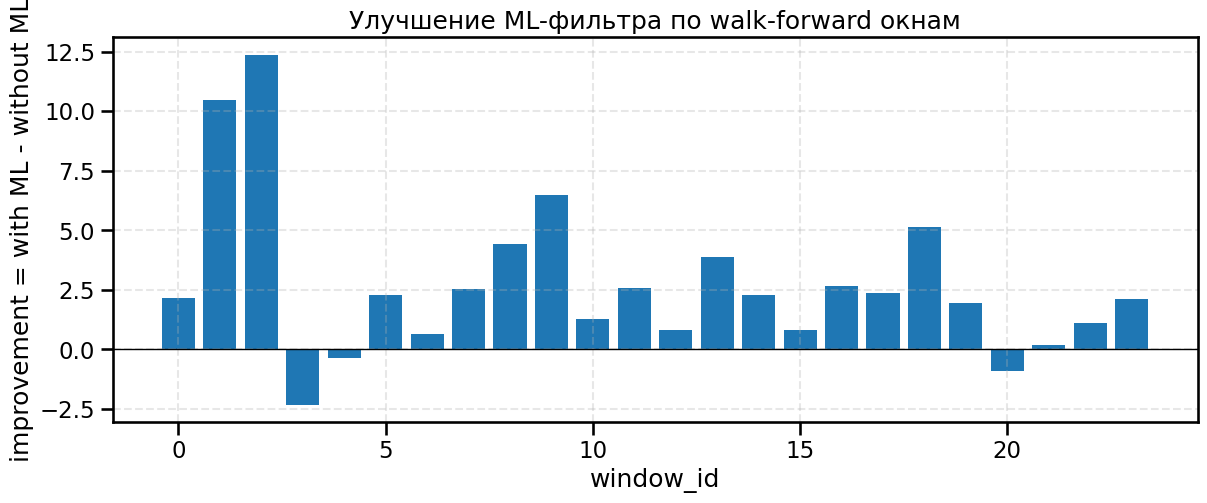

In [237]:
print("количество окон:", len(wf_stats))

print("доля окон, где ML улучшил результат:")
print((wf_stats["improvement"] > 0).mean())

print("суммарно без ML:")
print(wf_stats["total_return_without_ml"].sum())

print("суммарно с ML:")
print(wf_stats["total_return_with_ml"].sum())

print("суммарное улучшение:")
print(wf_stats["improvement"].sum())
wf_stats[[
    "window_id",
    "test_start",
    "test_end",
    "threshold",
    "trades_without_ml",
    "trades_with_ml",
    "winrate_without_ml",
    "winrate_with_ml",
    "total_return_without_ml",
    "total_return_with_ml",
    "improvement",
]]
plt.figure(figsize=(14, 5))

plt.bar(
    wf_stats["window_id"],
    wf_stats["improvement"]
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Улучшение ML-фильтра по walk-forward окнам")
plt.xlabel("window_id")
plt.ylabel("improvement = with ML - without ML")
plt.grid(True, alpha=0.3, linestyle="--")

plt.show()